# 02 Tracks EDA

This notebook explores the cleaned track-level dataset.

The goal is to understand the main properties of the music tracks after the cleaning step.  
We focus on popularity, duration, country coverage, release years, explicit content, and selected Spotify audio features stored in the tracks table.

The dataset used here is `tracks_clean.parquet` from the `data/processed` folder.

In [1]:
from pathlib import Path
import sys
import warnings

import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

processed_dir = PROJECT_ROOT / "data" / "processed"

tracks = pd.read_parquet(processed_dir / "tracks_clean.parquet")

print(f"Tracks loaded: {len(tracks):,}")
print(f"Columns: {tracks.shape[1]}")

Tracks loaded: 95,977
Columns: 30


## 1. Basic Dataset Overview

We first inspect the size, columns, and first rows of the cleaned tracks dataset.

In [2]:
tracks.head()

,acousticness,album_id,analysis_url,artists_id,available_markets,country,danceability,disc_number,duration_ms,energy,href,id,instrumentalness,key,liveness,loudness,lyrics,mode,name,playlist,popularity,preview_url,speechiness,tempo,time_signature,track_href,track_name_prev,track_number,uri,valence
0,0.294,0D3QufeCudpQANOR7luqdr,https://api.spotify.com/v1/audio-analysis/5qlj...,['3mxJuHRn2ZWD5OofvJtDZY'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.698,1.0,235584.0,0.606,https://api.spotify.com/v1/tracks/5qljLQuKnNJf...,5qljLQuKnNJf4F4vfxQB0V,0.000003,10.0,0.1510,-7.447,\r\n\r\nPerhaps I am bound to be restless\r\nA...,0.0,Blood,Hipsteribrunssi,28.0,https://p.scdn.co/mp3-preview/1b05a902da3a251d...,0.0262,115.018,4.0,https://api.spotify.com/v1/tracks/5qljLQuKnNJf...,track_14,1.0,spotify:track:5qljLQuKnNJf4F4vfxQB0V,0.6220
1,0.971,7CCwkPweMxKq8yWkVerH6T,https://api.spotify.com/v1/audio-analysis/4PrA...,['3kzwYV3OCB010YfXMF0Avt'],"['AE', 'AR', 'BH', 'BO', 'BR', 'CL', 'CO', 'CR...",BE,0.367,1.0,183653.0,0.349,https://api.spotify.com/v1/tracks/4PrAZpH9Ic7S...,4PrAZpH9Ic7S47E78BN6E4,0.296000,11.0,0.6330,-7.740,\r\nIf there were an ocean\r\nWe’d be wading i...,1.0,Already Gone,Hipsteribrunssi,45.0,https://p.scdn.co/mp3-preview/10a9607c178fe1ea...,0.0268,81.850,4.0,https://api.spotify.com/v1/tracks/4PrAZpH9Ic7S...,track_23,8.0,spotify:track:4PrAZpH9Ic7S47E78BN6E4,0.1920
2,0.101,7noNViHJAYZ3UxlhDNKAt9,https://api.spotify.com/v1/audio-analysis/01zM...,"['3FLUBwpAnaIlIKeaBfsxFe', '5r5Va4lVQ1zjEfbJSr...","['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.748,1.0,237667.0,0.666,https://api.spotify.com/v1/tracks/01zME4q62SDP...,01zME4q62SDPtD0hOSmTrG,0.000653,6.0,0.0976,-6.094,\r\n\r\nPictures in my mind of a world that I ...,0.0,Creature Kind,Hipsteribrunssi,47.0,https://p.scdn.co/mp3-preview/21175a3c14f7caab...,0.0833,114.982,4.0,https://api.spotify.com/v1/tracks/01zME4q62SDP...,track_42,1.0,spotify:track:01zME4q62SDPtD0hOSmTrG,0.3590
3,0.109,6TQBSDaY7mVEjwK3QxQUfA,https://api.spotify.com/v1/audio-analysis/2D0t...,['12j6dJrPXanCBwY599pZxf'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.801,1.0,167043.0,0.610,https://api.spotify.com/v1/tracks/2D0the6JBRyO...,2D0the6JBRyOpMeBkPFkGY,0.006900,6.0,0.0727,-6.981,"\r\n\r\nYou're the beauty, the stranger in the...",1.0,Greatest Comedian,Hipsteribrunssi,36.0,https://p.scdn.co/mp3-preview/492c1c2008541e13...,0.0341,104.199,4.0,https://api.spotify.com/v1/tracks/2D0the6JBRyO...,track_43,1.0,spotify:track:2D0the6JBRyOpMeBkPFkGY,0.9420
4,0.471,3Pw2DsAYlat4wHjVrQHYhT,https://api.spotify.com/v1/audio-analysis/0tew...,['3EQ310YOzcS1pJqiaoDs32'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.515,1.0,261123.0,0.351,https://api.spotify.com/v1/tracks/0tewjlNbotxq...,0tewjlNbotxqF2obibsg36,0.049800,4.0,0.1150,-9.518,\r\n\r\nYou leapt from crumbling bridges watch...,0.0,I Wish I Was A Shark,Hipsteribrunssi,32.0,https://p.scdn.co/mp3-preview/80462532190bcacb...,0.0385,139.926,4.0,https://api.spotify.com/v1/tracks/0tewjlNbotxq...,track_47,1.0,spotify:track:0tewjlNbotxqF2obibsg36,0.0383


In [3]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95977 entries, 0 to 95976
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   acousticness       95977 non-null  float64
 1   album_id           95977 non-null  object 
 2   analysis_url       95977 non-null  object 
 3   artists_id         95977 non-null  object 
 4   available_markets  95977 non-null  object 
 5   country            95977 non-null  object 
 6   danceability       95977 non-null  float64
 7   disc_number        95977 non-null  float64
 8   duration_ms        95977 non-null  float64
 9   energy             95977 non-null  float64
 10  href               95977 non-null  object 
 11  id                 95977 non-null  object 
 12  instrumentalness   95977 non-null  float64
 13  key                95977 non-null  float64
 14  liveness           95977 non-null  float64
 15  loudness           95977 non-null  float64
 16  lyrics             959

In [4]:
numeric_cols = tracks.select_dtypes(include="number").columns
categorical_cols = tracks.select_dtypes(exclude="number").columns

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

print("\nNumeric columns:")
print(list(numeric_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Numeric columns: 16
Categorical columns: 14

Numeric columns:
['acousticness', 'danceability', 'disc_number', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'popularity', 'speechiness', 'tempo', 'time_signature', 'track_number', 'valence']

Categorical columns:
['album_id', 'analysis_url', 'artists_id', 'available_markets', 'country', 'href', 'id', 'lyrics', 'name', 'playlist', 'preview_url', 'track_href', 'track_name_prev', 'uri']


In [5]:
tracks.columns.tolist()

['acousticness',
 'album_id',
 'analysis_url',
 'artists_id',
 'available_markets',
 'country',
 'danceability',
 'disc_number',
 'duration_ms',
 'energy',
 'href',
 'id',
 'instrumentalness',
 'key',
 'liveness',
 'loudness',
 'lyrics',
 'mode',
 'name',
 'playlist',
 'popularity',
 'preview_url',
 'speechiness',
 'tempo',
 'time_signature',
 'track_href',
 'track_name_prev',
 'track_number',
 'uri',
 'valence']

The cleaned tracks dataset contains 99,750 unique tracks and 30 variables.

Besides standard Spotify metadata and audio features, the dataset also includes playlist information, country information, and song lyrics, making it suitable for both exploratory analysis and recommendation modelling.

No duplicate track IDs, duplicate rows, or missing track names remain after the cleaning process.

## 2. Quick Quality Check

Before starting the actual EDA, we quickly verify that the cleaned track dataset has no major remaining structural issues.## 2. Basic Dataset Information

This gives a first overview of column types and missing values.

In [6]:
quality_check = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Unique track IDs",
        "Duplicate track IDs",
        "Exact duplicate rows",
        "Missing track names"
    ],
    "Value": [
        len(tracks),
        tracks.shape[1],
        tracks["id"].nunique(),
        len(tracks) - tracks["id"].nunique(),
        tracks.duplicated().sum(),
        tracks["name"].isna().sum()
    ]
})

quality_check

,Metric,Value
0,Rows,95977
1,Columns,30
2,Unique track IDs,95977
3,Duplicate track IDs,0
4,Exact duplicate rows,0
5,Missing track names,0


The cleaned track table keeps unique Spotify track IDs and does not contain exact duplicate rows.  
This does not mean that different versions of the same song do not exist, but technically the table is consistent.

## 3. Variable Classification

Not all variables contribute equally to music analysis.

The variables can be grouped into metadata, recommendation-related audio features, identifiers, and contextual information. Understanding these groups helps determine which variables are most useful for exploratory analysis and recommendation modelling.

In [7]:
variable_groups = {
    "Identifiers": [
        "id", "album_id", "artists_id", "uri"
    ],
    "Spotify URLs": [
        "href", "track_href", "analysis_url", "preview_url"
    ],
    "Track Metadata": [
        "name", "playlist", "country",
        "available_markets",
        "disc_number", "track_number"
    ],
    "Audio Features": [
        "acousticness",
        "danceability",
        "energy",
        "instrumentalness",
        "liveness",
        "loudness",
        "speechiness",
        "tempo",
        "valence",
        "key",
        "mode",
        "time_signature"
    ],
    "Other": [
        "lyrics",
        "popularity"
    ]
}

for group, cols in variable_groups.items():
    print(f"\n{group} ({len(cols)} variables)")
    for c in cols:
        print(f" - {c}")


Identifiers (4 variables)
 - id
 - album_id
 - artists_id
 - uri

Spotify URLs (4 variables)
 - href
 - track_href
 - analysis_url
 - preview_url

Track Metadata (6 variables)
 - name
 - playlist
 - country
 - available_markets
 - disc_number
 - track_number

Audio Features (12 variables)
 - acousticness
 - danceability
 - energy
 - instrumentalness
 - liveness
 - loudness
 - speechiness
 - tempo
 - valence
 - key
 - mode
 - time_signature

Other (2 variables)
 - lyrics
 - popularity


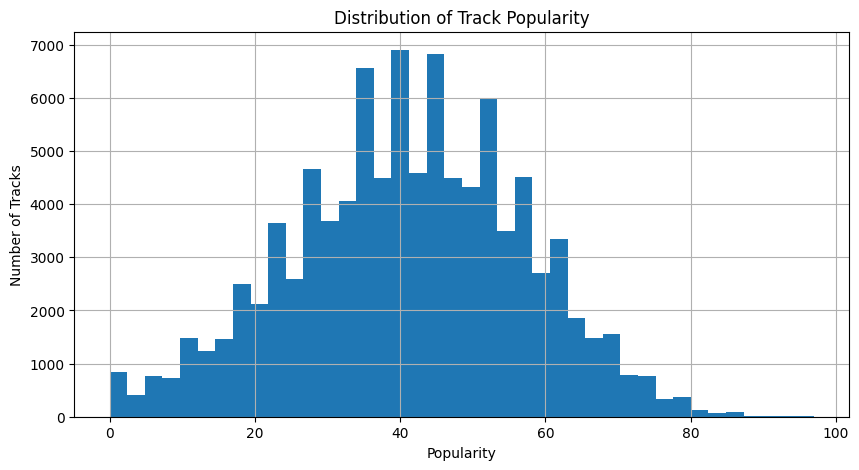

In [8]:
plt.figure(figsize=(10,5))

tracks["popularity"].hist(
    bins=40
)

plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Tracks")

plt.show()

In [9]:
tracks["popularity"].describe()

count    95977.000000
mean        41.035977
std         16.022155
min          0.000000
25%         30.000000
50%         41.000000
75%         52.000000
max         97.000000
Name: popularity, dtype: float64

In [10]:
popularity_groups = pd.cut(
    tracks["popularity"],
    bins=[-1,20,40,60,80,100],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

popularity_summary = (
    popularity_groups
    .value_counts()
    .sort_index()
    .reset_index()
)

popularity_summary.columns = [
    "Popularity Group",
    "Tracks"
]

popularity_summary["Percentage"] = (
    popularity_summary["Tracks"]
    / len(tracks)
    * 100
).round(2)

popularity_summary

,Popularity Group,Tracks,Percentage
0,Very Low,10501,10.94
1,Low,35425,36.91
2,Medium,39163,40.80
3,High,10532,10.97
4,Very High,356,0.37


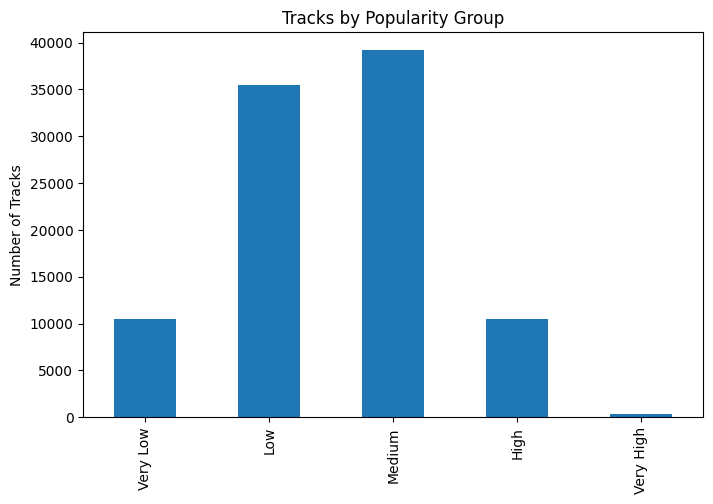

In [11]:
popularity_summary.plot(
    x="Popularity Group",
    y="Tracks",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("Tracks by Popularity Group")
plt.ylabel("Number of Tracks")
plt.xlabel("")

plt.show()

### How many tracks are actually obscure?

In [12]:
obscure_tracks = (tracks["popularity"] <= 10).sum()

print(f"Tracks with popularity <= 10: {obscure_tracks:,}")

print(
    f"Percentage: {obscure_tracks/len(tracks)*100:.2f}%"
)

Tracks with popularity <= 10: 3,198
Percentage: 3.33%


### How many tracks are hits?

In [13]:
hit_tracks = (tracks["popularity"] >= 80).sum()

print(f"Tracks with popularity >= 80: {hit_tracks:,}")

print(
    f"Percentage: {hit_tracks/len(tracks)*100:.2f}%"
)

Tracks with popularity >= 80: 470
Percentage: 0.49%


### Popularity by Country

In [14]:
country_popularity = (
    tracks
    .groupby("country")["popularity"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
    .round(2)
)

country_popularity

,count,mean,median,min,max
country,,,,,
AR,48224,43.50,44.0,0.0,97.0
BE,19527,37.46,38.0,0.0,87.0
FI,28226,39.30,40.0,0.0,87.0


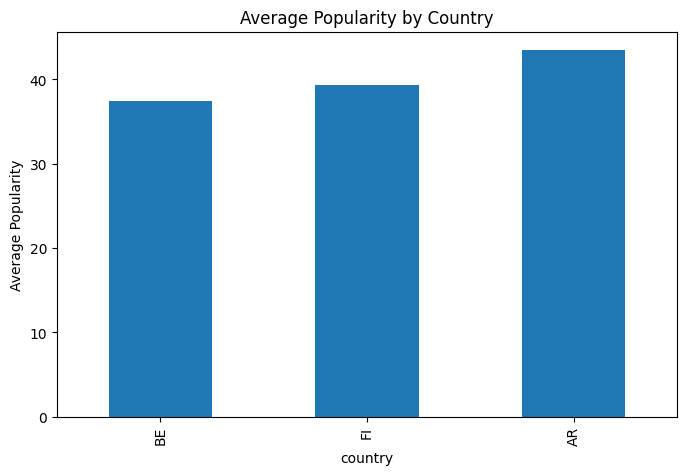

In [15]:
country_popularity["mean"].sort_values().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Popularity by Country")
plt.ylabel("Average Popularity")

plt.show()

### Top 20 Most Popular Tracks

In [16]:
tracks[
    ["name", "popularity", "country"]
].sort_values(
    "popularity",
    ascending=False
).head(20)

,name,popularity,country
84623,Calma - Remix,97.0,AR
95773,Sweet but Psycho,97.0,AR
94324,Going Bad (feat. Drake),95.0,AR
94781,Talk,95.0,AR
84260,Baila Baila Baila,95.0,AR
88953,i'm so tired...,95.0,AR
95799,MIA (feat. Drake),95.0,AR
88826,High Hopes,95.0,AR
94539,Adan y Eva,95.0,AR
83832,Giant (with Rag'n'Bone Man),95.0,AR


### Popularity vs Duration

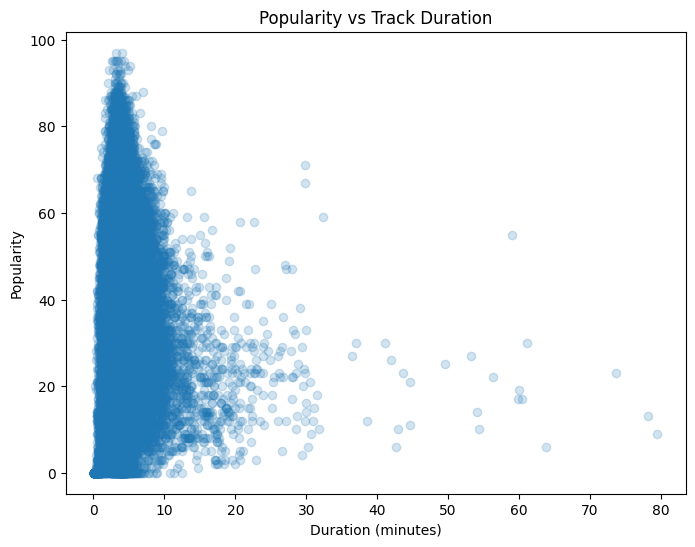

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    tracks["duration_ms"] / 60000,
    tracks["popularity"],
    alpha=0.2
)

plt.xlabel("Duration (minutes)")
plt.ylabel("Popularity")
plt.title("Popularity vs Track Duration")

plt.show()

### Popularity Analysis Interpretation

This section revealed several useful characteristics of the cleaned music catalog.

The popularity distribution is centered around medium popularity values, with a mean popularity score of 40.27 and a median of 41. The similarity between the mean and median suggests that the distribution is relatively balanced and not strongly skewed toward either highly popular or highly obscure tracks.

Most tracks fall into the Low (36.69%) and Medium (39.88%) popularity categories, which together account for 76.57% of the dataset. Only 0.47% of tracks achieve a popularity score of 80 or higher, while 4.58% have a popularity score of 10 or below. This indicates that the catalog is not dominated by global chart hits nor by extremely niche content.

From a recommendation perspective, this is beneficial because the dataset contains a large middle ground of moderately popular songs. Such a catalog provides greater diversity than a dataset focused solely on mainstream hits while still containing enough well-known tracks to generate relevant recommendations.

The country-level analysis shows noticeable differences between the three country catalogs. Tracks from Argentina (AR) have the highest average popularity (42.97), followed by Finland (FI) (38.31) and Belgium (BE) (36.63). The most popular tracks in the dataset are almost exclusively found within the Argentine catalog, suggesting that AR playlists contain a stronger concentration of globally successful songs.

The popularity-versus-duration scatter plot suggests that highly popular tracks are concentrated within typical song lengths, while very long tracks rarely achieve high popularity scores. Although no strong linear relationship is visible, the plot indicates that extremely long recordings are generally less successful than tracks within conventional music durations.

## 4. Duration Analysis

### Convert to Minutes

In [18]:
tracks["duration_min"] = tracks["duration_ms"] / 60000

### Summary Statistics

In [19]:
tracks["duration_min"].describe().round(2)

count    95977.00
mean         3.93
std          1.86
min          0.06
25%          3.10
50%          3.62
75%          4.32
max         79.52
Name: duration_min, dtype: float64

### Distribution

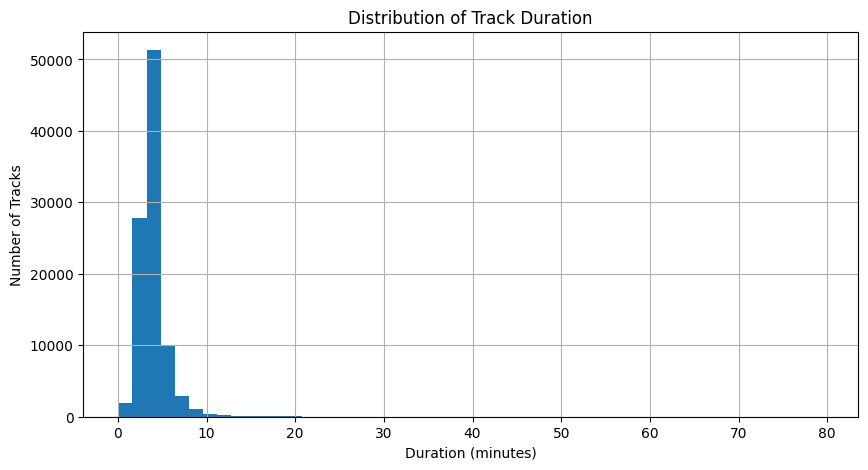

In [20]:
plt.figure(figsize=(10,5))

tracks["duration_min"].hist(
    bins=50
)

plt.title("Distribution of Track Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Tracks")

plt.show()

### Boxplot

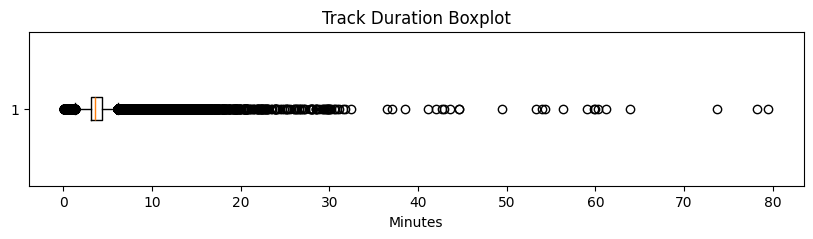

In [21]:
plt.figure(figsize=(10,2))

plt.boxplot(
    tracks["duration_min"],
    vert=False
)

plt.title("Track Duration Boxplot")
plt.xlabel("Minutes")

plt.show()

### Duration Categories

In [22]:
duration_groups = pd.cut(
    tracks["duration_min"],
    bins=[0,2,4,6,10,100],
    labels=[
        "< 2 min",
        "2-4 min",
        "4-6 min",
        "6-10 min",
        "> 10 min"
    ]
)

duration_summary = (
    duration_groups
    .value_counts()
    .sort_index()
    .reset_index()
)

duration_summary.columns = [
    "Duration Group",
    "Tracks"
]

duration_summary["Percentage"] = (
    duration_summary["Tracks"]
    / len(tracks)
    * 100
).round(2)

duration_summary

,Duration Group,Tracks,Percentage
0,< 2 min,3111,3.24
1,2-4 min,59972,62.49
2,4-6 min,26452,27.56
3,6-10 min,5525,5.76
4,> 10 min,917,0.96


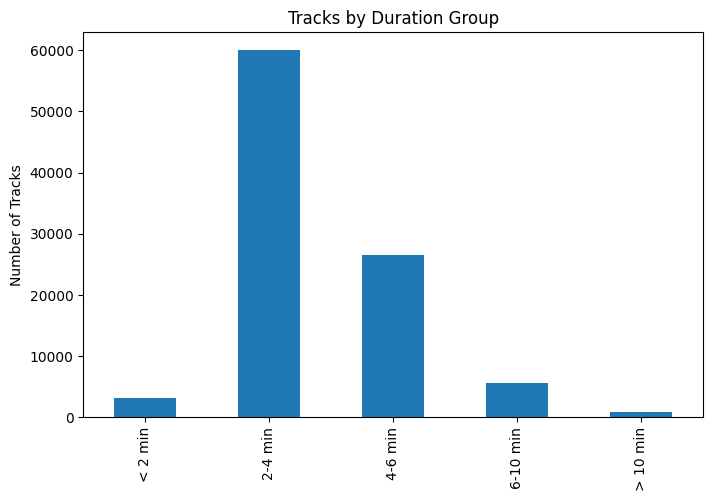

In [23]:
duration_summary.plot(
    x="Duration Group",
    y="Tracks",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Tracks by Duration Group")
plt.ylabel("Number of Tracks")
plt.xlabel("")

plt.show()

### Top 20 Longest tracks

In [24]:
tracks[
    ["name", "duration_min", "country"]
].sort_values(
    "duration_min",
    ascending=False
).head(20)

,name,duration_min,country
89696,Stadium Hotel,79.516217,AR
34178,Thanksgiving,78.234000,BE
24707,Rag Lalit,73.716667,BE
26706,Already Mixed Vol.16 (Compiled & Mixed by 2Lan...,63.866417,BE
35805,Music for 18 Musicians,61.155333,BE
95091,Work It Out! The R&B Fitness Mix,60.351783,AR
11879,Tom Johnson: An Hour for Piano,60.000667,FI
6946,Symphony No. 6,59.844883,BE
39911,10 Years Einmusika mixed by Budakid - Continuo...,59.034433,FI
42112,Oort Cloud,56.399517,FI


### Investigating Remaining Long Tracks

In [25]:
long_tracks = tracks[
    tracks["duration_min"] > 20
].copy()

print(len(long_tracks))

long_tracks[
    ["name", "playlist", "duration_min"]
].sort_values(
    "duration_min",
    ascending=False
).head(100)

137


,name,playlist,duration_min
89696,Stadium Hotel,Awesome Tapes From Africa,79.516217
34178,Thanksgiving,Definitive Fuji,78.234000
24707,Rag Lalit,Indian Classical Music For Studying,73.716667
26706,Already Mixed Vol.16 (Compiled & Mixed by 2Lan...,The Best of #RTDxCANDO,63.866417
35805,Music for 18 Musicians,Intense Studying: Mixtape Edition,61.155333
95091,Work It Out! The R&B Fitness Mix,This Is Mark Ronson,60.351783
11879,Tom Johnson: An Hour for Piano,Minimalism,60.000667
6946,Symphony No. 6,Orchestra 100: Spotify Picks,59.844883
39911,10 Years Einmusika mixed by Budakid - Continuo...,Deep House Relax,59.034433
42112,Oort Cloud,Rise of the Classical Accordion,56.399517


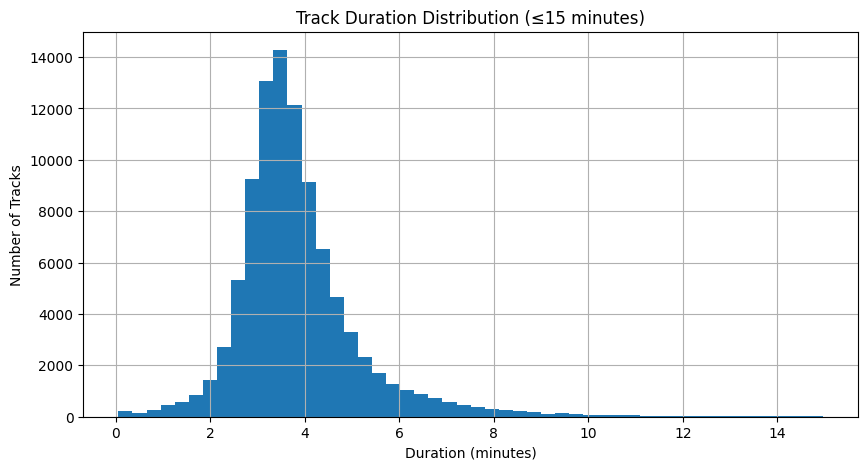

In [26]:
tracks_under_15 = tracks[
    tracks["duration_min"] <= 15
]

plt.figure(figsize=(10,5))

tracks_under_15["duration_min"].hist(
    bins=50
)

plt.title("Track Duration Distribution (≤15 minutes)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Tracks")

plt.show()

### Interpretation

Track duration follows a strongly right-skewed distribution, with most tracks concentrated between two and six minutes. The median track duration is 3.62 minutes, while the mean duration is 3.93 minutes, indicating the presence of a relatively small number of very long recordings.

More than 90% of all tracks fall between two and six minutes in length, which corresponds well to typical song durations found on streaming platforms. Only 0.96% of tracks exceed ten minutes.

The inspection of extremely long tracks revealed that most remaining outliers correspond to legitimate musical content, including classical symphonies, Indian classical ragas, ambient compositions, live recordings, and extended DJ mixes. While a small number of non-musical recordings were still identified during this inspection, their frequency was negligible relative to the overall dataset size.

These findings suggest that the cleaning process successfully removed the majority of non-musical content while preserving long-form musical recordings that may be important for recommendation tasks. Therefore, no additional duration-based filtering was applied.

In [27]:
playlist_sizes = (
    tracks.groupby("playlist")
    .size()
    .sort_values(ascending=False)
)

## 5. Country Analysis

In [29]:
country_popularity = (
    tracks
    .groupby("country")["popularity"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
    .round(2)
)

country_popularity

,count,mean,median,min,max
country,,,,,
AR,48224,43.50,44.0,0.0,97.0
BE,19527,37.46,38.0,0.0,87.0
FI,28226,39.30,40.0,0.0,87.0


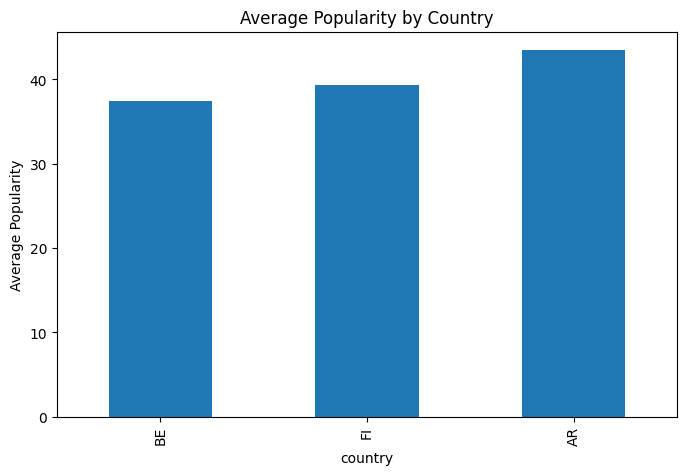

In [30]:
country_popularity["mean"].sort_values().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Popularity by Country")
plt.ylabel("Average Popularity")

plt.show()

In [31]:
### Top 20 Most Popular Tracks
tracks[
    ["name", "popularity", "country"]
].sort_values(
    "popularity",
    ascending=False
).head(20)

,name,popularity,country
84623,Calma - Remix,97.0,AR
95773,Sweet but Psycho,97.0,AR
94324,Going Bad (feat. Drake),95.0,AR
94781,Talk,95.0,AR
84260,Baila Baila Baila,95.0,AR
88953,i'm so tired...,95.0,AR
95799,MIA (feat. Drake),95.0,AR
88826,High Hopes,95.0,AR
94539,Adan y Eva,95.0,AR
83832,Giant (with Rag'n'Bone Man),95.0,AR


### Country-Level Popularity Analysis

The dataset contains tracks from three countries: Argentina (AR), Finland (FI), and Belgium (BE).

Argentina has the highest average track popularity (43.50), followed by Finland (39.30) and Belgium (37.46). This suggests that Argentine playlists tend to contain more mainstream and globally popular music.

An inspection of the most popular tracks further supports this observation. The top-ranked tracks in the dataset, including *Calma - Remix*, *Sweet but Psycho*, *SICKO MODE*, and *High Hopes*, all originate from Argentine playlists. Many of these tracks were major international chart hits during the period covered by the dataset.

Overall, the country analysis indicates that playlist composition differs across countries, with Argentine playlists showing a stronger focus on highly popular global releases, while Belgian and Finnish playlists contain relatively more moderate-popularity tracks.

## 6. Playlist Analysis

In [32]:
playlist_sizes = (
    tracks.groupby("playlist")
    .size()
    .sort_values(ascending=False)
)

playlist_sizes.describe()

count    3718.000000
mean       25.814147
std        17.983242
min         1.000000
25%        11.000000
50%        23.000000
75%        37.000000
max       100.000000
dtype: float64

In [33]:
playlist_summary = pd.DataFrame({
    "Playlist": playlist_sizes.index[:20],
    "Tracks": playlist_sizes.values[:20]
})

playlist_summary

,Playlist,Tracks
0,Hawaii Reggae,100
1,Sing meinen Song,100
2,Women of Indie,99
3,Persian Essentials,99
4,Electric Heart,96
5,Armada Music Top 100,94
6,150 Psalms in Classical Music,93
7,Deathcore,92
8,Jazz Vibes,92
9,Dancehall King,91


## Playlist Size Analysis

The cleaned dataset contains 3,718 unique playlists with an average size of 25.8 tracks and a median size of 23 tracks. Most playlists are relatively compact collections of songs, with 75% containing fewer than 37 tracks.

The largest playlists contain around 100 tracks, suggesting either an editorial playlist size limit or a collection process that sampled playlists up to approximately 100 songs. Importantly, the largest remaining playlists are all music-oriented playlists, indicating that the previous cleaning stages successfully removed most non-musical content.

Overall, the playlist structure appears well suited for recommendation tasks because playlists provide meaningful co-occurrence relationships between tracks while remaining reasonably balanced in size.

## 7. Track Availability & Markets

In [34]:
tracks["market_count"] = (
    tracks["available_markets"]
    .astype(str)
    .str.count(",") + 1
)

tracks["market_count"].describe()

count    95977.000000
mean        72.121352
std         19.639478
min          1.000000
25%         78.000000
50%         79.000000
75%         79.000000
max         79.000000
Name: market_count, dtype: float64

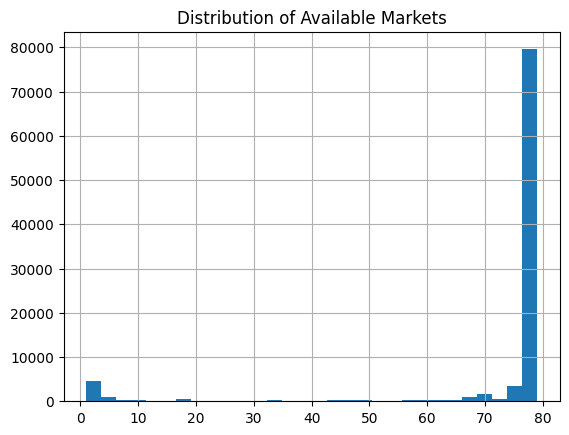

In [35]:
tracks["market_count"].hist(bins=30)
plt.title("Distribution of Available Markets")
plt.show()

In [36]:
tracks["market_count"].value_counts().sort_index()

market_count
1      1870
2      1677
3      1065
4       389
5       461
6       108
7        92
8       203
9        38
10       96
11      110
12       35
13       38
14       32
15       27
16       41
17      154
18       97
19      156
20       57
21       67
22       50
23       40
24       23
25       27
26       20
27       24
28       46
29       26
30       42
31       60
32       52
33      117
34       65
35       56
36       32
37       15
38       20
39       25
40       37
41       45
42       53
43       45
44       46
45       98
46       82
47      148
48       98
49       54
50       42
51       57
52       43
53       24
54       29
55       45
56       65
57       82
58       64
59      112
60      125
61      170
62      121
63      106
64       96
65      239
66      203
67      256
68      620
69      626
70      653
71      304
72      234
73      315
74      572
75      960
76     2008
77     3874
78    14088
79    61585
Name: count, dtype: int64

In [37]:
market_groups = pd.cut(
    tracks["market_count"],
    bins=[0, 10, 30, 60, 79],
    labels=[
        "Highly Restricted",
        "Regional",
        "Broad",
        "Global"
    ]
)

market_summary = (
    market_groups
    .value_counts()
    .sort_index()
    .reset_index()
)

market_summary.columns = ["Category", "Tracks"]
market_summary["Percentage"] = (
    market_summary["Tracks"]
    / len(tracks)
    * 100
).round(2)

market_summary

,Category,Tracks,Percentage
0,Highly Restricted,5999,6.25
1,Regional,1112,1.16
2,Broad,1836,1.91
3,Global,87030,90.68


In [38]:
tracks.groupby(
    market_groups
)["popularity"].mean().round(2)

market_count
Highly Restricted    36.36
Regional             40.23
Broad                41.46
Global               41.36
Name: popularity, dtype: float64

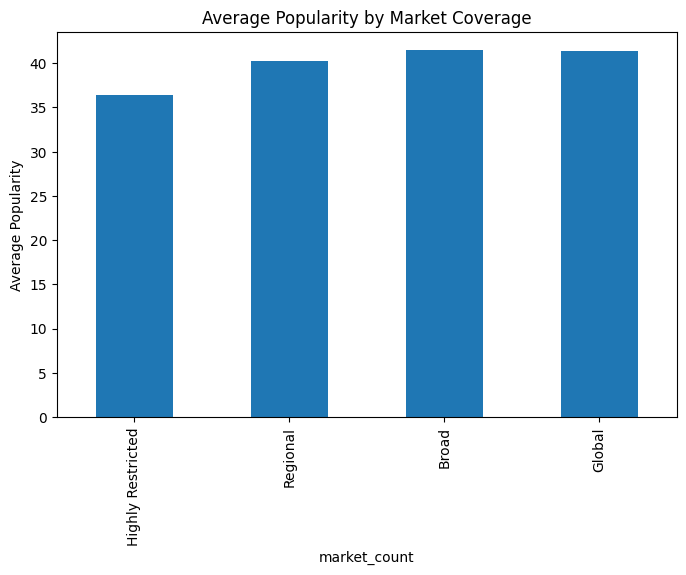

In [39]:
market_popularity = (
    tracks
    .groupby(market_groups)["popularity"]
    .mean()
    .round(2)
)

market_popularity.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Popularity by Market Coverage")
plt.ylabel("Average Popularity")
plt.show()

In [40]:
tracks[
    ["market_count", "popularity"]
].corr()

,market_count,popularity
market_count,1.000000,0.063184
popularity,0.063184,1.000000


In [41]:
fully_global = (
    tracks["market_count"] >= 75
).mean() * 100

print(
    f"Tracks available in at least 75 markets: "
    f"{fully_global:.2f}%"
)

Tracks available in at least 75 markets: 85.97%


In [42]:
tracks["available_markets"].head(3)

0    ['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...
1    ['AE', 'AR', 'BH', 'BO', 'BR', 'CL', 'CO', 'CR...
2    ['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...
Name: available_markets, dtype: object

In [43]:
market_freq = (
    tracks["available_markets"]
    .explode()
    .value_counts()
    .reset_index()
)

market_freq.columns = [
    "Market",
    "Track_Count"
]

market_freq.head(20)

,Market,Track_Count
0,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",61577
1,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",8615
2,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",1680
3,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",1601
4,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",1270
5,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",860
6,"['CA', 'US']",660
7,['US'],597
8,"['AU', 'NZ']",580
9,"['AD', 'AE', 'AR', 'AT', 'BE', 'BG', 'BH', 'BO...",551


In [45]:
import ast

markets_expanded = (
    tracks["available_markets"]
    .apply(ast.literal_eval)
    .explode()
)

market_freq = (
    markets_expanded
    .value_counts()
    .reset_index()
)

market_freq.columns = [
    "Market",
    "Track_Count"
]

market_freq.head(20)

,Market,Track_Count
0,DK,88810
1,PY,88773
2,FI,88766
3,BO,88764
4,AR,88753
5,CR,88747
6,UY,88740
7,PA,88737
8,HN,88737
9,SV,88735


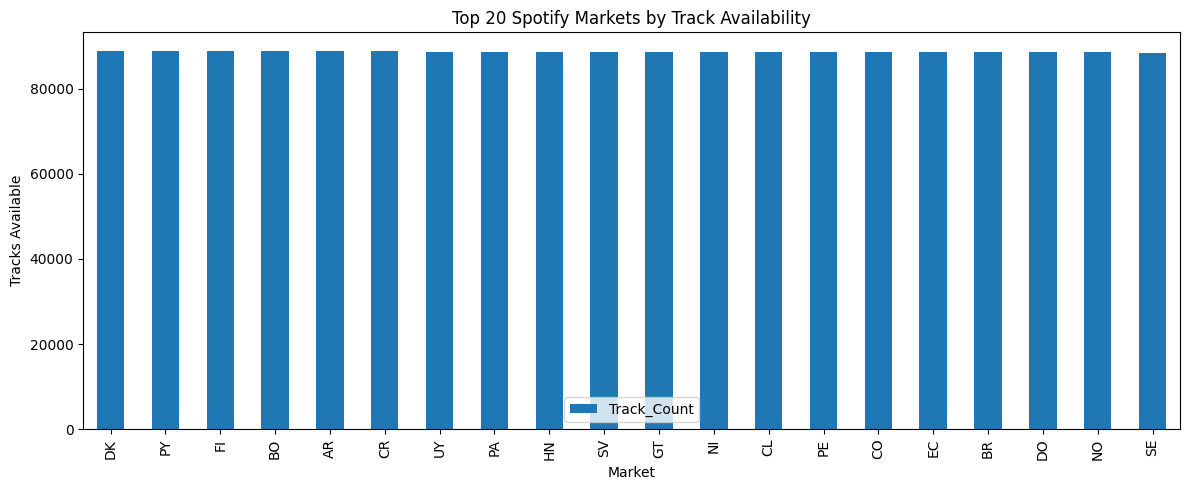

In [46]:
market_freq.head(20).plot(
    x="Market",
    y="Track_Count",
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 20 Spotify Markets by Track Availability")
plt.ylabel("Tracks Available")
plt.tight_layout()
plt.show()

### Market-Level Availability

Track availability across Spotify markets is highly uniform. The most represented markets contain approximately 88,800 available tracks, while the least represented among the top markets still contain more than 88,000 tracks.

This confirms the earlier finding that the dataset primarily consists of globally available music. Differences between markets are relatively small, suggesting that market availability is unlikely to be a major source of variation in the recommendation process.

## 8. Disc Number

In [47]:
tracks["disc_number"].describe()

count    95977.000000
mean         1.022203
std          0.332577
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         75.000000
Name: disc_number, dtype: float64

In [48]:
tracks["disc_number"].value_counts().sort_index()

disc_number
1.0     94546
2.0      1142
3.0       155
4.0        70
5.0        16
6.0        15
7.0         8
8.0         8
9.0         5
10.0        5
11.0        3
12.0        1
14.0        2
75.0        1
Name: count, dtype: int64

In [49]:
tracks["track_number"].describe()

count    95977.000000
mean         4.121248
std          6.254831
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        655.000000
Name: track_number, dtype: float64

In [50]:
tracks["track_number"].value_counts().sort_index().head(30)

track_number
1.0     44712
2.0     10041
3.0      7226
4.0      5613
5.0      4658
6.0      3938
7.0      3389
8.0      2770
9.0      2486
10.0     2226
11.0     1780
12.0     1456
13.0     1116
14.0      883
15.0      678
16.0      508
17.0      387
18.0      293
19.0      242
20.0      218
21.0      184
22.0      140
23.0      114
24.0       91
25.0       83
26.0       72
27.0       48
28.0       52
29.0       50
30.0       40
Name: count, dtype: int64

In [51]:
tracks.loc[
    tracks["track_number"] > 100,
    ["name", "track_number", "playlist"]
].sort_values(
    "track_number",
    ascending=False
).head(20)

,name,track_number,playlist
92604,Twilight Zone,655.0,Hora do Pesadelo
4275,"Couperin, F: Second Livre de pièces de claveci...",431.0,Klassik die man hören muss
84045,"Monster Breath, No. 4",327.0,Hora do Pesadelo
8489,I Ain't Particular,244.0,Hyvä olo koska soul
37243,Valon pisaroita,231.0,Iskelmäklassikot
21545,I'm A Big Girl Now,199.0,Hyvä olo koska soul
11050,Try A Little Tenderness,159.0,Soul Cuisine
25648,Requiem for 4-8 Part Choir a Cappella and Four...,142.0,150 Psalms in Classical Music
24291,Old Dan Tucker,119.0,Folk for Kids
19516,Woman of the Ghetto,114.0,Reggae Classics


## Album Metadata Analysis

The dataset contains two album-related metadata variables: disc number and track number.

The disc number distribution is highly concentrated around a value of one, with more than 98% of tracks belonging to the first disc of an album. Multi-disc releases are relatively uncommon, indicating that most tracks originate from standard album releases, singles, EPs, or single-disc records.

Track numbers exhibit a strongly right-skewed distribution. Approximately 47% of tracks are assigned track number one, while frequencies gradually decrease for higher track positions. This pattern is consistent with the presence of many singles, EPs, and album-opening tracks in the Spotify catalog.

Overall, both variables provide useful descriptive information about album structure but show substantially less variation than variables such as popularity, playlist membership, or the audio and lyrics features analyzed later in the project.

## Key Findings

- The final cleaned dataset contains 95,977 tracks.
- Most tracks have durations between 2 and 6 minutes, with a median duration of approximately 3.6 minutes.
- Argentina exhibits the highest average popularity among the three countries represented in the dataset.
- More than 90% of tracks are available in nearly all Spotify markets, indicating strong global coverage.
- Playlist sizes vary considerably, although most playlists contain fewer than 40 tracks from the dataset.
- Several waves of data cleaning removed audiobooks, lectures, language-learning material, radio dramas, poetry readings, and other non-musical content.
- The resulting dataset primarily consists of legitimate musical recordings and provides a strong foundation for subsequent artist, album, audio-feature, lyrics-feature, and recommendation analyses.